In [54]:
import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath('src'))

from src.config import SIM_CONFIG
from src.users import generate_users
from src.sessions import generate_sessions
from src.events import generate_events
from src.orders import generate_orders
from src.order_items import generate_order_items

rng = np.random.default_rng(seed=42)
print("modules loaded successfully.")

modules loaded successfully.


In [55]:
test_users_df = generate_users(total_users=1000000, rng=rng)
display(test_users_df.head())

Generating 1000000 users
users table generated!


,user_id,account_created_at,city,region,user_tenure_days,latent_income_score,latent_digital_literacy,latent_trust_in_platform
0,4a25f85da2d84ab5917165777a85a337,2024-11-28 04:21:20,davao_del_norte,region_xi,32,0.334835,0.039387,0.498106
1,3b75d63e227c46589a320811d42c4590,2024-03-23 15:20:48,cebu,region_vii,282,0.078654,0.700104,0.049789
2,dd9831051f2c4ebba9f499b835de0f69,2024-05-06 06:09:19,siquijor,nir,238,0.836328,0.424339,0.271859
3,23a6d8c2ba594fbba3084385c876f381,2024-07-23 22:47:29,makati,ncr,160,0.999611,0.141295,0.104224
4,a30c036d5a854546b073a177bb16ec13,2024-07-25 08:38:11,cavite,region_iv-a,158,1.000962,0.595593,0.166513


In [56]:
test_sessions_df = generate_sessions(df_users=test_users_df, rng=rng)
display(test_sessions_df.head())

Generating 1900888 sessions
sessions table generated!


,session_id,user_id,session_number,acq_channel,utm_source,utm_medium,utm_campaign,session_start_time,session_end_time,session_duration_seconds,device_operating_system,device_operating_system_version,device_group
0,aceec1c7e6d14ddc88b81b71a81c48df,4a25f85da2d84ab5917165777a85a337,1,meta,facebook,cpc,retargeting,2024-12-03 17:27:38,2024-12-03 17:29:27,109,ios,17.3,mobile
1,c0089c2927c44f37b4f218b1ede8e892,3b75d63e227c46589a320811d42c4590,1,organic,google,organic,(not_set),2024-03-24 05:00:56,2024-03-24 05:02:08,72,android,14,mobile
2,97f4081aa9a747968e46caca22122bae,dd9831051f2c4ebba9f499b835de0f69,1,organic,google,organic,(not_set),2024-11-12 18:00:37,2024-11-12 18:08:44,487,macos,monterey,desktop
3,ddd22b3d09b84e75af76d7e11e0e9332,23a6d8c2ba594fbba3084385c876f381,1,organic,google,organic,(not_set),2024-08-01 13:06:43,2024-08-01 13:07:24,41,macos,monterey,desktop
4,f91c8128392b4a1f82e3cca9890929ac,23a6d8c2ba594fbba3084385c876f381,2,tiktok,tiktok,cpc,summer_vibes,2024-07-24 11:51:43,2024-07-24 12:06:29,886,windows,11,desktop


In [57]:
test_events_df = generate_events(df_sessions=test_sessions_df, df_users=test_users_df, rng=rng, n_workers=1)
display(test_events_df.head())

Generating events for 1900888 sessions


,event_id,session_id,event_timestamp,event_name,viewed_category,android_error
0,0f217e4a-1b68-4edd-b2f1-3442b467ea6a,aceec1c7e6d14ddc88b81b71a81c48df,2024-12-03 17:27:38,view_item,consumer_electronics,NaN
1,ac79e0c4-137c-4490-a53b-c67bb2927505,c0089c2927c44f37b4f218b1ede8e892,2024-03-24 05:00:56,view_item,beauty_and_personal_care,NaN
2,6689e06c-f8c1-4835-b238-13483a663d28,c0089c2927c44f37b4f218b1ede8e892,2024-03-24 05:01:08,add_to_cart,beauty_and_personal_care,NaN
3,010f17c1-6e52-4109-9d5e-2b8aeaf53580,c0089c2927c44f37b4f218b1ede8e892,2024-03-24 05:01:19,view_cart,beauty_and_personal_care,NaN
4,b37a9c18-82b7-4955-b23e-da30ed669c15,97f4081aa9a747968e46caca22122bae,2024-11-12 18:00:37,view_item,fashion_and_apparel,NaN


In [58]:
test_orders_df = generate_orders(df_events=test_events_df, df_sessions=test_sessions_df, rng=rng)
display(test_orders_df.head())

Generating 59430 orders for purchases events
orders table generated!


,order_id,session_id,user_id,order_timestamp,payment_type
0,c603f97a85d84190a7be6638080c791d,f3840a97ad774c92b7edfa1b5609e00b,c98de74ccfc04b358cdf5eaa8ee5aa79,2024-07-06 13:43:33,cash_payments
1,dc329400dddd48a29e7bf65b7e2720e3,08887d4ef6e74363be7959dffee32101,30d3c275785740bc8ddc6931608d07fb,2024-02-17 10:11:51,credit_card
2,a1f6671ed22348d1811d10a583d2169c,498cac142ea5420489fff7baa0bd52c7,970b94a3b9164e0db19c5d593ca10ca7,2024-03-19 17:09:51,buy_now_pay_later
3,fe79a7bd8a1a4850907c4815ecf3e4a6,619c60ca6dfb454498990aeea4f83371,e26925e7316c4b3ab1ab1455e6a64fbb,2024-03-30 09:23:54,cod
4,8b865da36ec047d79f45553dbea6606d,c8ff484d8c474b75a811b3acf2d40fcb,e26925e7316c4b3ab1ab1455e6a64fbb,2024-07-02 08:37:45,credit_card


In [59]:
test_order_items_df = generate_order_items(df_orders=test_orders_df, df_users=test_users_df, rng=rng)
display(test_order_items_df.head())

Generating order items for 59430 orders
order items table generated!


,order_item_id,order_id,item_category,base_item_price,final_item_price,quantity,discount_percentage
0,4cba6e729f714a0b86c95c0483dd65d3,c603f97a85d84190a7be6638080c791d,beauty_and_personal_care,294.99,294.99,1,0.00
1,6453b48c55954aa9a482b2313412575f,dc329400dddd48a29e7bf65b7e2720e3,fashion_and_apparel,41.99,33.59,1,0.20
2,4773e41ab83749f28e013643796a9d82,a1f6671ed22348d1811d10a583d2169c,food_and_beverage,132.99,132.99,2,0.00
3,0d8bd71d2a4a4588ac2a9916dfa9208b,fe79a7bd8a1a4850907c4815ecf3e4a6,food_and_beverage,160.99,160.99,1,0.00
4,ac04f815c575408c8a68cbc5c1f211c1,fe79a7bd8a1a4850907c4815ecf3e4a6,beauty_and_personal_care,317.99,270.29,1,0.15


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def internal_validation(df_users, df_sessions, df_events, df_orders, df_order_items):
    print("=== BEGINNING INTERNAL DAG VALIDATION ===")

    # 1. Checking referential integrity
    purchase_sessions = df_events[df_events['event_name'] == 'purchase']['session_id'].unique()
    orphaned_orders = df_orders[~df_orders['session_id'].isin(purchase_sessions)]
    
    print("\n1. Referential Integrity:")
    if orphaned_orders.empty:
        print("   ✅ PASS: All orders have a corresponding 'purchase' event.")
    else:
        print(f"   ❌ FAIL: Found {len(orphaned_orders)} orders without a purchase event!")
        
    # 2. Funnel baseline calibration (markov chain)
    print("\n2. Markov Chain Funnel Calibration:")
    event_counts = df_events['event_name'].value_counts()
    views = event_counts.get('view_item', 1)
    purchases = event_counts.get('purchase', 0)
    conversion_rate = (purchases / views) * 100
    print(f"   Total Views: {views:,}")
    print(f"   Total Purchases: {purchases:,}")
    print(f"   View-to-Purchase Conversion Rate: {conversion_rate:.2f}% (Target: ~2.25%)")
    
    if 1.5 <= conversion_rate <= 3.0:
        print("   ✅ PASS: Conversion rate is within realistic bounds.")
    else:
        print("   ⚠️ WARNING: Conversion rate is drifting from target.")

    # 3. Behavioral Decay Assertion (Exponential)
    print(f"\n3. Temporal Decay (Digital Literacy vs. Session Duration):")
    # Merge sessions with users to access the exact column name: latent_digital_literacy
    df_sess_user = df_sessions.merge(df_users[['user_id', 'latent_digital_literacy']], on='user_id')
    
    try:
        # Calculate the deciles and the trend
        df_sess_user['literacy_decile'] = pd.qcut(df_sess_user['latent_digital_literacy'].rank(method='first'), q=10, labels=False)
        decay_trend = df_sess_user.groupby('literacy_decile')['session_duration_seconds'].mean()
        
        # Extract the exact mean durations for the lowest (0) and highest (9) deciles
        lowest_literacy_mean = decay_trend.iloc[0]
        highest_literacy_mean = decay_trend.iloc[-1]
        
        is_decreasing = lowest_literacy_mean > highest_literacy_mean
        if is_decreasing:
            print("✅ PASS: Higher digital literacy results in lower mean session duration.")
            print(f"   -> Bottom 10% Literacy (Novice): Avg {lowest_literacy_mean:.2f} seconds per session")
            print(f"   -> Top 10% Literacy (Expert): Avg {highest_literacy_mean:.2f} seconds per session")
            print(f"   -> Difference: Experts navigate {lowest_literacy_mean - highest_literacy_mean:.2f} seconds faster.")
        else:
            print("❌ FAIL: Session duration does not correlate correctly with digital literacy.")
            print(f"   -> Bottom 10% Mean: {lowest_literacy_mean:.2f}s | Top 10% Mean: {highest_literacy_mean:.2f}s")
    except Exception as e:
        print(f"⚠️ Could not calculate deciles. Error: {e}")
        
    # 4. Financial Distribution Assertion (Log-Normal)
    print("\n4. Financial Shift (Latent Income vs. Base Price):")
    df_fin = df_order_items.merge(df_orders[['order_id', 'user_id']], on='order_id')
    df_fin = df_fin.merge(df_users[['user_id', 'latent_income_score']], on='user_id')
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_fin, x='latent_income_score', y='base_item_price', alpha=0.3)
    plt.title("Internal Validation: Latent Income vs Item Price")
    plt.xlabel("Latent Income Score")
    plt.ylabel("Base Item Price (₱)")
    plt.show()

=== BEGINNING INTERNAL DAG VALIDATION ===

1. Referential Integrity:
   ✅ PASS: All orders have a corresponding 'purchase' event.

2. Markov Chain Funnel Calibration:
   Total Views: 2,577,398
   Total Purchases: 59,430
   View-to-Purchase Conversion Rate: 2.31% (Target: ~2.25%)
   ✅ PASS: Conversion rate is within realistic bounds.

3. Temporal Decay (Digital Literacy vs. Session Duration):
✅ PASS: Higher digital literacy results in lower mean session duration.
   -> Bottom 10% Literacy (Novice): Avg 318.97 seconds per session
   -> Top 10% Literacy (Expert): Avg 207.69 seconds per session
   -> Difference: Experts navigate 111.28 seconds faster.

4. Financial Shift (Latent Income vs. Base Price):


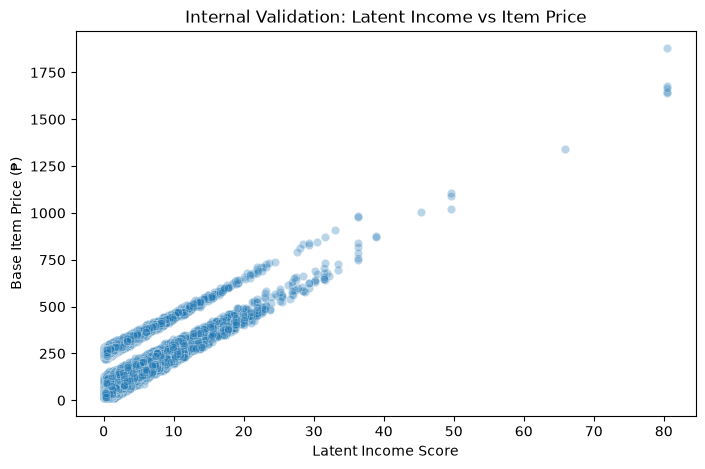

In [66]:
# Run the internal DAG and math validation
internal_validation(test_users_df, test_sessions_df, test_events_df, test_orders_df, test_order_items_df)